# Tema 1 — Exercițiul 3

## Probabilitatea unui frizer

Probabilitatea de preluare este rata fiecărui frizer împărțită la suma ratelor:

$$P_i = \frac{\lambda_i}{\lambda_1 + \lambda_2 + \lambda_3} = \frac{\lambda_i}{3 + 6 + 4} = \frac{\lambda_i}{13}$$

adică $3/13$, $6/13$, $4/13$.

## Generarea celor 10000 de valori

Pentru fiecare client alegem un frizer conform probabilităților, apoi generăm timpul de servire din distribuția exponențială a frizerului respectiv (scale = $1/\lambda$).

In [1]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

lambdas = np.array([3, 6, 4])
probabilitati = lambdas / lambdas.sum()

n = 10000
frizeri = np.random.choice([0, 1, 2], size=n, p=probabilitati)
X = np.random.exponential(scale=1 / lambdas[frizeri])

## Media și deviația standard

In [2]:
print(f"Media: {X.mean():.4f} h")
print(f"Deviația standard: {X.std():.4f} h")

Media: 0.2305 h
Deviația standard: 0.2487 h


## Densitatea aproximativă a lui $X$

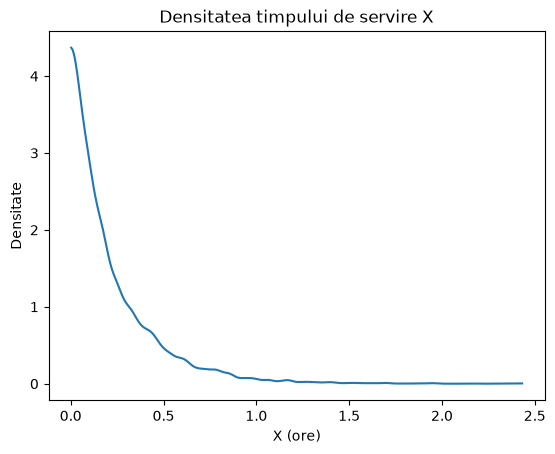

In [3]:
grid, densitate, _ = az.kde(X)
plt.plot(grid, densitate)
plt.title("Densitatea timpului de servire X")
plt.xlabel("X (ore)")
plt.ylabel("Densitate")
plt.show()